# 10 - VGG16 desde cero usando arrays

Entrena VGG16 sin pesos preentrenados (`weights=None`) usando el dataset preprocesado de arrays (`X_all.npy`). Se diferencia del `09_resnet_scratch` porque compara otra arquitectura clasica profunda entrenada desde cero, sin transfer learning.


## Librerias y configuracion


In [1]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

RUN_START = time.perf_counter()

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


2026-06-02 15:23:02.797661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780413783.013641      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780413783.077489      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780413783.612673      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780413783.612713      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780413783.612716      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
SEED = 42
BATCH_SIZE = 32
EPOCHS = 50
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)

np.random.seed(SEED)
tf.random.set_seed(SEED)


## Datos


### Localizacion de inputs


In [3]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

array_matches = sorted(KAGGLE_INPUT_DIR.rglob('X_all.npy'))
working_candidate = WORKDIR / 'xview_arrays' / 'X_all.npy'
if working_candidate.exists():
    array_matches = [working_candidate] + array_matches

if not array_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro X_all.npy. Anade el dataset xview_arrays creado con 00_1. '
        f'Inputs disponibles: {available_inputs}'
    )

ARRAYS_ROOT = array_matches[0].parent

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json. Anade tambien el dataset original xview_recognition. '
        f'Inputs disponibles: {available_inputs}'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('ARRAYS_ROOT:', ARRAYS_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


ARRAYS_ROOT: /kaggle/input/datasets/eccvdl/xview-arrays/xview_arrays
DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


### Lectura de arrays


In [4]:
DATA_LOAD_START = time.perf_counter()

X_all = np.load(ARRAYS_ROOT / 'X_all.npy')
y_all_idx = np.load(ARRAYS_ROOT / 'y_all_idx.npy')
filenames = np.load(ARRAYS_ROOT / 'filenames.npy')
image_ids = np.load(ARRAYS_ROOT / 'image_ids.npy')
category_names = np.load(ARRAYS_ROOT / 'category_names.npy').astype(str).tolist()
num_classes = len(category_names)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape)
print('image_ids:', image_ids.shape)
print('num_classes:', num_classes)
print(category_names)


X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,)
image_ids: (18746,)
num_classes: 13
['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Image id: 0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Primeros pixeles del array original:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]
Primeros pixeles normalizados:
[[[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.18039216 0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]]


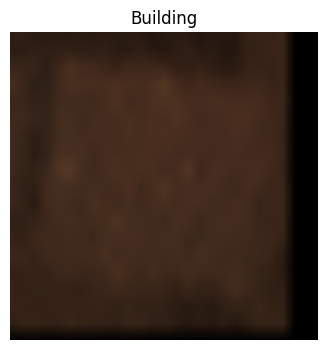

In [5]:
sample_idx = 0
sample_img = X_all[sample_idx]
sample_label_idx = int(y_all_idx[sample_idx])

print('Filename:', filenames[sample_idx])
print('Image id:', image_ids[sample_idx])
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', category_names[sample_label_idx])
print('Primeros pixeles del array original:')
print(sample_img[:3, :3, :])
print('Primeros pixeles normalizados:')
print((sample_img.astype(np.float32) / 255.0)[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(category_names[sample_label_idx])
plt.axis('off')
plt.show()


### Split train/valid


In [6]:
indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes=num_classes).astype(np.float32)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)
print(f'Tiempo carga arrays/split: {DATA_LOAD_TIME:.2f} s')


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32
Tiempo carga arrays/split: 19.89 s


## Red


### VGG16 desde cero


In [7]:
inputs = tf.keras.Input(shape=IMAGE_SHAPE)
x = tf.keras.layers.Rescaling(1.0 / 255.0)(inputs)

base = tf.keras.applications.VGG16(
    include_top=False,
    weights=None,
    input_tensor=x,
)

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='vgg16_scratch')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


I0000 00:00:1780413854.921405      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780413854.927371      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "vgg16_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,849,357 (56.65 MB)

 Trainable params: 14,849,357 (56.65 MB)

 Non-trainable params: 0 (0.00 B)

### Callbacks


In [8]:
MODEL_PATH = WORKDIR / '10_vgg16_scratch_arrays.keras'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_PATH), monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.TerminateOnNaN(),
]


### Entrenamiento


In [9]:
TRAIN_START = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

TRAIN_TIME = time.perf_counter() - TRAIN_START

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)
print(f'Tiempo entrenamiento: {TRAIN_TIME:.2f} s')


Epoch 1/50


I0000 00:00:1780413865.657282     131 service.cc:152] XLA service 0x7ca220005530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780413865.657335     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780413865.657343     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780413866.549639     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-02 15:24:45.023848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:24:45.218211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:24:46.924238: E external/local_xl

497/498 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.1810 - loss: 2.3650

2026-06-02 15:29:45.859267: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:29:46.064310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:29:47.937007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:29:48.115045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:29:52.468440: E external/local_xla/xla/stream_

498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.1811 - loss: 2.3649
Epoch 1: val_accuracy improved from None to 0.23151, saving model to /kaggle/working/10_vgg16_scratch_arrays.keras

Epoch 1: finished saving model to /kaggle/working/10_vgg16_scratch_arrays.keras
498/498 ━━━━━━━━━━━━━━━━━━━━ 393s 704ms/step - accuracy: 0.1927 - loss: 2.3296 - val_accuracy: 0.2315 - val_loss: 2.2711 - learning_rate: 1.0000e-04
Epoch 2/50
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.2544 - loss: 2.2103
Epoch 2: val_accuracy improved from 0.23151 to 0.35597, saving model to /kaggle/working/10_vgg16_scratch_arrays.keras

Epoch 2: finished saving model to /kaggle/working/10_vgg16_scratch_arrays.keras
498/498 ━━━━━━━━━━━━━━━━━━━━ 280s 563ms/step - accuracy: 0.2935 - loss: 2.1147 - val_accuracy: 0.3560 - val_loss: 1.9479 - learning_rate: 1.0000e-04
Epoch 3/50
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.3381 - loss: 1.9831
Epoch 3: val_accuracy improved from 0.35597 to 0.35633

## Resultados


### Graficas


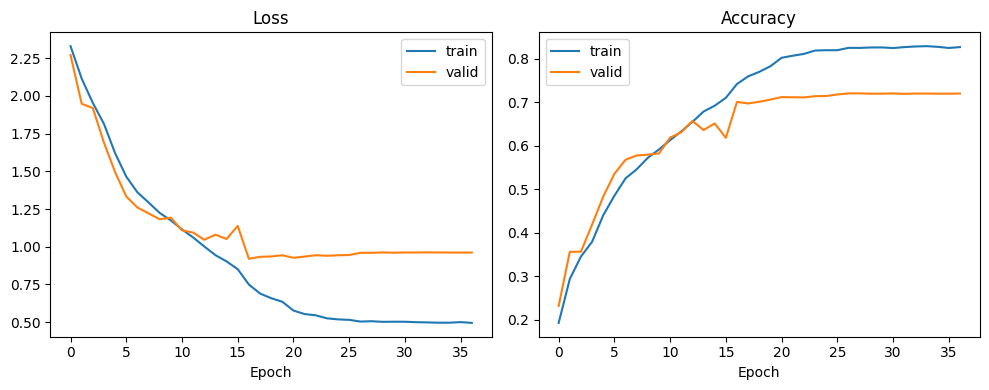

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


### Predicciones de validacion


In [11]:
model.load_weights(MODEL_PATH)

valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
print('Validation loss:', valid_loss)
print('Validation accuracy:', valid_accuracy)

probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx


88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.7201 - loss: 0.9598
Validation loss: 0.9597674012184143
Validation accuracy: 0.7201279997825623
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step


### Matriz de confusion


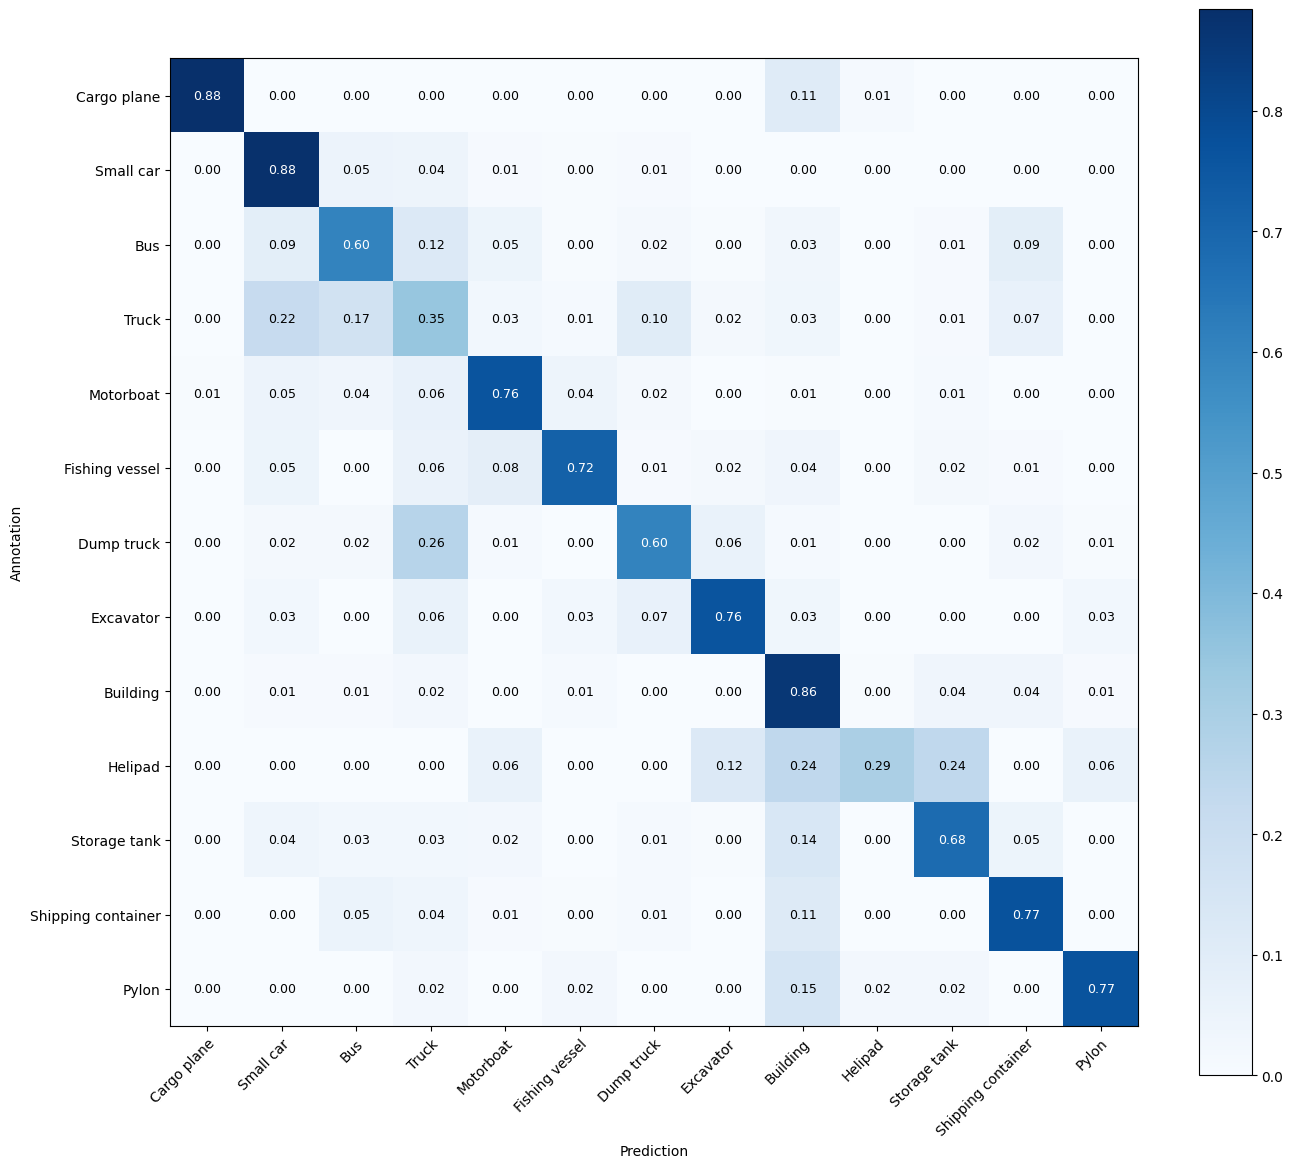

In [12]:
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))

def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    fig.tight_layout()
    plt.show()
    return cm_norm

cm_norm = draw_confusion_matrix_percent(cm, category_names)


### Metricas


In [13]:
print(classification_report(y_true_idx, y_pred_idx, target_names=category_names, digits=4))


                    precision    recall  f1-score   support

       Cargo plane     0.9767    0.8842    0.9282        95
         Small car     0.7739    0.8778    0.8225       499
               Bus     0.5824    0.6000    0.5911       265
             Truck     0.4307    0.3464    0.3840       332
         Motorboat     0.7349    0.7625    0.7485       160
    Fishing vessel     0.7451    0.7170    0.7308       106
        Dump truck     0.6416    0.6000    0.6201       185
         Excavator     0.7895    0.7627    0.7759       118
          Building     0.8109    0.8590    0.8342       539
           Helipad     0.5556    0.2941    0.3846        17
      Storage tank     0.8152    0.6818    0.7426       220
Shipping container     0.6875    0.7686    0.7258       229
             Pylon     0.8000    0.7660    0.7826        47

          accuracy                         0.7201      2812
         macro avg     0.7188    0.6862    0.6978      2812
      weighted avg     0.7132    0.720

## Codabench


### Generacion del submission


In [14]:
CODABENCH_START = time.perf_counter()

def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))

test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_10.json'
submission_path = WORKDIR / 'submission_10.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_10.json - 727749 bytes
/kaggle/working/submission_10.zip - 163504 bytes
Tiempo Codabench: 90.73 s


/kaggle/working/submission_10.zip

### Resumen de tiempos


In [15]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'TRAIN_TIME' in globals():
    print(f'- Entrenamiento: {TRAIN_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 19.89 s
- Entrenamiento: 10650.89 s
- Codabench: 90.73 s
- Tiempo total Run All: 10839.74 s
- Tiempo total Run All: 180.66 min
